# Project:
#  Fake News Detection using Machine Learning

# Technologies:
   Python

   Pandas

   Scikit-learn

   TF-IDF

   Linear SVM

   Streamlit
   
   Joblib

# Final Features:
   1. Single news article classification
   2. Prediction confidence
   3. Fake / Real probabilities
   4. CSV batch prediction
   5. Download batch results
   6. Model comparison
   7. Performance visualizations
   8. Confusion matrix
   9. Methodology
  10. Project disclaimer

STEP 1 — DATA LOADING, CLEANING & TEXT PREPROCESSING

1. IMPORT REQUIRED LIBRARIES

In [1]:
import os
import re
import string
import warnings
import numpy as np
import pandas as pd
from google.colab import files
warnings.filterwarnings("ignore")
print("=" * 70)
print("FAKE NEWS DETECTION SYSTEM USING MACHINE LEARNING")
print("STEP-1 1 — DATA LOADING, CLEANING & PREPROCESSING")
print("=" * 70)

FAKE NEWS DETECTION SYSTEM USING MACHINE LEARNING
STEP-1 1 — DATA LOADING, CLEANING & PREPROCESSING


2. CREATE PROJECT DIRECTORIES

In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("sample_data", exist_ok=True)
print("\nProject directories created successfully.")


Project directories created successfully.


3. UPLOAD DATASETS

In [3]:
print("\nPlease upload Fake.csv and True.csv")
uploaded_files = files.upload()
print("\nUploaded files:")
for filename in uploaded_files.keys():
    print("✓", filename)


Please upload Fake.csv and True.csv


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv

Uploaded files:
✓ Fake.csv
✓ True.csv


4. LOAD DATASETS

In [4]:
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"Fake dataset shape : {fake_df.shape}")
print(f"Real dataset shape : {real_df.shape}")


DATASET INFORMATION
Fake dataset shape : (23481, 4)
Real dataset shape : (21417, 4)


5. ADD CLASS LABELS

In [5]:
# Label definition:
# 0 = Fake
# 1 = Real
fake_df["label"] = 0
real_df["label"] = 1

6. COMBINE DATASETS

In [6]:
df = pd.concat(
    [fake_df, real_df],
    ignore_index=True
)
print(f"\nCombined dataset shape: {df.shape}")


Combined dataset shape: (44898, 5)


7. CREATE COMBINED TEXT FIELD

In [7]:
 # The model uses both the headline and article body.
 df["content"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["text"].fillna("").astype(str)
)
print("\nCombined title + article text successfully.")


Combined title + article text successfully.


8. CHECK MISSING VALUES

In [8]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64


9. REMOVE DUPLICATE RECORDS

In [9]:
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset after duplicate removal: {df.shape}")


Duplicate rows found: 209
Dataset after duplicate removal: (44689, 6)


10. TEXT CLEANING FUNCTION

In [10]:
def clean_text(text):
    """
    Clean news article text before TF-IDF vectorization.
    Operations:
    - Convert text to lowercase
    - Remove URLs
    - Remove HTML tags
    - Remove numbers
    - Remove punctuation
    - Remove extra whitespace
    """
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # Remove numbers
    text = re.sub(r"\d+", " ", text)
    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


11. APPLY TEXT PREPROCESSING

In [11]:
print("\nCleaning text...")
df["cleaned_content"] = df["content"].apply(clean_text)
print("Text preprocessing completed successfully.")


Cleaning text...
Text preprocessing completed successfully.


 12. DISPLAY SAMPLE

In [12]:
print("\n" + "=" * 70)
print("PREPROCESSING VERIFICATION")
print("=" * 70)
print("\nOriginal text:")
print(df.loc[0, "content"][:700])
print("\nCleaned text:")
print(df.loc[0, "cleaned_content"][:700])


PREPROCESSING VERIFICATION

Original text:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, e

Cleaned text:
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishones

13. DATASET SUMMARY

In [13]:
print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print(f"Total records : {len(df):,}")
print(f"Fake articles : {(df['label'] == 0).sum():,}")
print(f"Real articles : {(df['label'] == 1).sum():,}")
print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())
print("\nMissing values:")
print(
    df[
        ["title", "text", "subject", "date",
         "label", "content", "cleaned_content"]
    ].isnull().sum()
)
print("\n" + "=" * 70)
print("STEP 1 COMPLETED SUCCESSFULLY")
print("=" * 70)


FINAL DATASET SUMMARY
Total records : 44,689
Fake articles : 23,478
Real articles : 21,211

Label distribution:
label
0    23478
1    21211
Name: count, dtype: int64

Missing values:
title              0
text               0
subject            0
date               0
label              0
content            0
cleaned_content    0
dtype: int64

STEP 1 COMPLETED SUCCESSFULLY


# STEP 2 — TF-IDF FEATURE EXTRACTION

1. IMPORT REQUIRED LIBRARIES

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
print("=" * 70)
print("STEP 2 — TF-IDF FEATURE EXTRACTION")
print("=" * 70)

STEP 2 — TF-IDF FEATURE EXTRACTION


2. DEFINE FEATURES AND TARGET

In [15]:
X = df["cleaned_content"]
y = df["label"]
print("\nFeature shape:", X.shape)
print("Target shape :", y.shape)
print("\nFirst processed article:")
print(X.iloc[0][:500])
print("\nFirst label:")
print(y.iloc[0])


Feature shape: (44689,)
Target shape : (44689,)

First processed article:
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest fake news media a happy and hea

First label:
0


3. STRATIFIED TRAIN-TEST SPLIT

In [16]:
# 80% training
# 20% testing
# random_state = 42 for reproducibility
# stratify maintains class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")
print("\nTraining label distribution:")
print(y_train.value_counts().sort_index())
print("\nTesting label distribution:")
print(y_test.value_counts().sort_index())


TRAIN-TEST SPLIT
Training samples: 35,751
Testing samples : 8,938

Training label distribution:
label
0    18782
1    16969
Name: count, dtype: int64

Testing label distribution:
label
0    4696
1    4242
Name: count, dtype: int64


4. CREATE TF-IDF VECTORIZER

In [17]:
# Parameters:
# - stop_words='english'
# - max_df=0.7
# - min_df=2
# - ngram_range=(1,2) -> unigrams + bigrams
# - sublinear_tf=True

tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)
print("\nTF-IDF vectorizer created successfully.")


TF-IDF vectorizer created successfully.


5. FIT TF-IDF ONLY ON TRAINING DATA

In [18]:
print("\nFitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)


Fitting TF-IDF on training data...


6. TRANSFORM TEST DATA

In [19]:
print("Transforming test data...")
X_test_tfidf = tfidf.transform(X_test)

Transforming test data...


7. DISPLAY TF-IDF RESULTS

In [20]:
print("\n" + "=" * 70)
print("TF-IDF TRANSFORMATION COMPLETED")
print("=" * 70)
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape :", X_test_tfidf.shape)
print(
    f"\nNumber of TF-IDF features: "
    f"{X_train_tfidf.shape[1]:,}"
)


TF-IDF TRANSFORMATION COMPLETED
Training matrix shape: (35751, 1232340)
Testing matrix shape : (8938, 1232340)

Number of TF-IDF features: 1,232,340


8. SAVE TRAIN/TEST INFORMATION FOR LATER USE

In [21]:
np.save(
    "results/y_test.npy",
    y_test.to_numpy()
)
print("\nTest labels saved successfully.")
print("\n" + "=" * 70)
print("STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 70)


Test labels saved successfully.

STEP 2 COMPLETED SUCCESSFULLY


# PART 3 — MODEL TRAINING, EVALUATION & VISUALIZATION

1. IMPORT REQUIRED LIBRARIES

In [22]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
print("=" * 70)
print("STEP 3 — MODEL TRAINING, EVALUATION & VISUALIZATION")
print("=" * 70)

STEP 3 — MODEL TRAINING, EVALUATION & VISUALIZATION


2. DEFINE MODELS

In [23]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB()

}


 3. TRAIN AND EVALUATE ALL MODELS

In [24]:
results = []
trained_models = {}
predictions = {}
for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(f"TRAINING {model_name.upper()}")
    print("=" * 70)
    # Train model
    model.fit(X_train_tfidf, y_train)
    # Predict test data
    y_pred = model.predict(X_test_tfidf)
    # Store trained model and predictions
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    print(f"\n{model_name} Results")
    print("-" * 45)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


TRAINING LOGISTIC REGRESSION

Logistic Regression Results
---------------------------------------------
Accuracy : 0.9888
Precision: 0.9848
Recall   : 0.9917
F1 Score : 0.9883

TRAINING LINEAR SVM

Linear SVM Results
---------------------------------------------
Accuracy : 0.9977
Precision: 0.9967
Recall   : 0.9983
F1 Score : 0.9975

TRAINING MULTINOMIAL NAIVE BAYES

Multinomial Naive Bayes Results
---------------------------------------------
Accuracy : 0.9618
Precision: 0.9487
Recall   : 0.9722
F1 Score : 0.9603


4. CREATE MODEL COMPARISON TABLE

In [25]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))


MODEL COMPARISON
                  Model  Accuracy  Precision   Recall  F1 Score
             Linear SVM  0.997650   0.996705 0.998350  0.997527
    Logistic Regression  0.988812   0.984785 0.991749  0.988255
Multinomial Naive Bayes  0.961848   0.948700 0.972183  0.960298


5. SELECT BEST MODEL

In [26]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("\n" + "=" * 70)
print("BEST MODEL SELECTION")
print("=" * 70)

print(f"Selected Model : {best_model_name}")
print(
    f"Accuracy       : "
    f"{results_df.iloc[0]['Accuracy']:.4f}"
)
print(
    f"Precision      : "
    f"{results_df.iloc[0]['Precision']:.4f}"
)
print(
    f"Recall         : "
    f"{results_df.iloc[0]['Recall']:.4f}"
)
print(
    f"F1 Score       : "
    f"{results_df.iloc[0]['F1 Score']:.4f}"
)

print("\nReason for Selection:")
print(
    f"{best_model_name} achieved the highest overall "
    "performance among the evaluated models, including "
    "the highest F1-score."
)


BEST MODEL SELECTION
Selected Model : Linear SVM
Accuracy       : 0.9977
Precision      : 0.9967
Recall         : 0.9983
F1 Score       : 0.9975

Reason for Selection:
Linear SVM achieved the highest overall performance among the evaluated models, including the highest F1-score.


6. SAVE MODEL COMPARISON RESULTS

In [27]:
results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

7. CLASSIFICATION REPORT

In [28]:
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — BEST MODEL")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Fake", "Real"]
    )
)


CLASSIFICATION REPORT — BEST MODEL
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



 8. CONFUSION MATRIX


Confusion Matrix:
[[4682   14]
 [   7 4235]]


<Figure size 700x600 with 0 Axes>

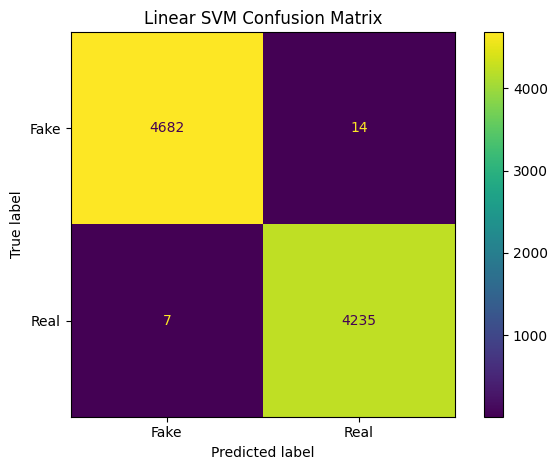

In [29]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "results/linear_svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

9. MODEL ACCURACY VISUALIZATION

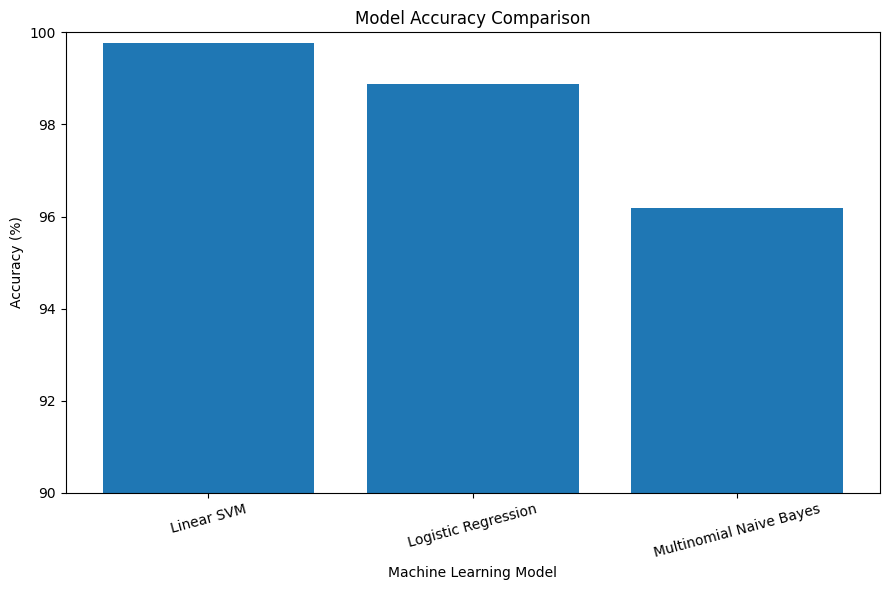

In [30]:
plt.figure(figsize=(9, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(90, 100)

plt.tight_layout()

plt.savefig(
    "results/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


10. COMPLETE METRICS VISUALIZATION

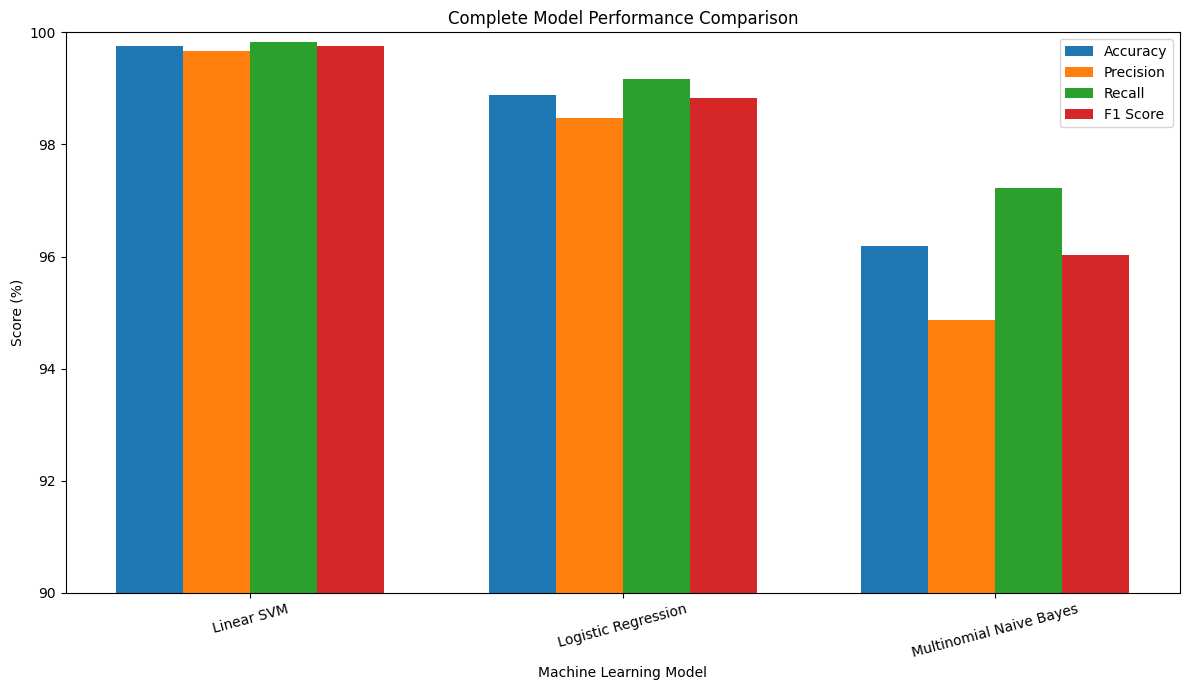

In [31]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(results_df["Model"]))
width = 0.18

plt.figure(figsize=(12, 7))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 1.5) * width,
        results_df[metric] * 100,
        width,
        label=metric
    )

plt.xticks(
    x,
    results_df["Model"],
    rotation=15
)

plt.ylabel("Score (%)")
plt.xlabel("Machine Learning Model")
plt.title("Complete Model Performance Comparison")
plt.ylim(90, 100)
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/model_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


11. SAVE BEST MODEL PERFORMANCE

In [32]:
best_metrics = results_df.iloc[0].to_dict()

pd.DataFrame([best_metrics]).to_csv(
    "results/best_model_performance.csv",
    index=False
)


print("\n" + "=" * 70)
print("PART 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nGenerated files:")
print("✓ results/model_comparison.csv")
print("✓ results/best_model_performance.csv")
print("✓ results/model_accuracy_comparison.png")
print("✓ results/model_metrics_comparison.png")
print("✓ results/linear_svm_confusion_matrix.png")


PART 3 COMPLETED SUCCESSFULLY

Generated files:
✓ results/model_comparison.csv
✓ results/best_model_performance.csv
✓ results/model_accuracy_comparison.png
✓ results/model_metrics_comparison.png
✓ results/linear_svm_confusion_matrix.png


# STEP 4 — CALIBRATION, FINAL MODEL & SAVING

1. IMPORT REQUIRED LIBRARIES

In [33]:
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
print("=" * 70)
print("STEP 4 — FINAL MODEL, CALIBRATION & SAVING")
print("=" * 70)

STEP 4 — FINAL MODEL, CALIBRATION & SAVING


2. VERIFY BEST MODEL

In [34]:
print("\nBase model selected:")
print(best_model_name)
if best_model_name != "Linear SVM":
    raise ValueError(
        "Unexpected best model. "
        "This project expects Linear SVM."
    )


Base model selected:
Linear SVM


3. CREATE CALIBRATED LINEAR SVM

In [35]:
# LinearSVC does not provide predict_proba().
# Calibration converts its decision scores into
# probability estimates for deployment confidence
calibrated_svm = CalibratedClassifierCV(
    estimator=LinearSVC(random_state=42),
    method="sigmoid",
    cv=3
)

print("\nTraining calibrated Linear SVM...")

calibrated_svm.fit(
    X_train_tfidf,
    y_train
)

print("Calibration completed successfully.")



Training calibrated Linear SVM...
Calibration completed successfully.


4. EVALUATE CALIBRATED MODEL

In [36]:
calibrated_predictions = calibrated_svm.predict(
    X_test_tfidf
)

calibrated_accuracy = accuracy_score(
    y_test,
    calibrated_predictions
)

calibrated_precision = precision_score(
    y_test,
    calibrated_predictions
)

calibrated_recall = recall_score(
    y_test,
    calibrated_predictions
)

calibrated_f1 = f1_score(
    y_test,
    calibrated_predictions
)

print("\n" + "=" * 70)
print("CALIBRATED LINEAR SVM PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {calibrated_accuracy:.4f}")
print(f"Precision: {calibrated_precision:.4f}")
print(f"Recall   : {calibrated_recall:.4f}")
print(f"F1 Score : {calibrated_f1:.4f}")


CALIBRATED LINEAR SVM PERFORMANCE
Accuracy : 0.9972
Precision: 0.9967
Recall   : 0.9974
F1 Score : 0.9971


5. CREATE DEPLOYMENT PIPELINE

In [37]:
# The pipeline contains:
# Raw Text
#    ↓
# TF-IDF Vectorizer
#    ↓
# Calibrated Linear SVM
#    ↓
# Prediction + Probability
deployment_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", calibrated_svm)
])


6. SAVE COMPLETE DEPLOYMENT MODEL

In [38]:
MODEL_PATH = (
    "models/fake_news_calibrated_pipeline.pkl"
)

joblib.dump(
    deployment_pipeline,
    MODEL_PATH
)

print("\nDeployment model saved:")
print(MODEL_PATH)


Deployment model saved:
models/fake_news_calibrated_pipeline.pkl


 7. VERIFY SAVED MODEL

In [39]:
loaded_model = joblib.load(
    MODEL_PATH
)

print("\nModel loaded successfully.")


Model loaded successfully.


8. TEST SAVED MODEL WITH SAMPLE NEWS

In [40]:
sample_news = """
WASHINGTON (Reuters) - Government officials announced
today that lawmakers are reviewing a proposed policy
following discussions with senior administration officials.
The review is expected to continue over the coming weeks.
"""

saved_prediction = loaded_model.predict(
    [sample_news]
)[0]

saved_probabilities = loaded_model.predict_proba(
    [sample_news]
)[0]

fake_probability = saved_probabilities[0]
real_probability = saved_probabilities[1]

if saved_prediction == 0:
    predicted_label = "FAKE"
    confidence = fake_probability
else:
    predicted_label = "REAL"
    confidence = real_probability



9. DISPLAY VERIFICATION RESULT

In [41]:
print("\n" + "=" * 70)
print("SAVED MODEL VERIFICATION")
print("=" * 70)

print(f"Prediction : {predicted_label}")
print(f"Confidence : {confidence * 100:.2f}%")

print("\nFake Probability:")
print(f"{fake_probability * 100:.2f}%")

print("\nReal Probability:")
print(f"{real_probability * 100:.2f}%")

print("\n✓ Model loaded successfully.")
print("✓ Prediction generated successfully.")
print("✓ Probability estimation working successfully.")


SAVED MODEL VERIFICATION
Prediction : REAL
Confidence : 100.00%

Fake Probability:
0.00%

Real Probability:
100.00%

✓ Model loaded successfully.
✓ Prediction generated successfully.
✓ Probability estimation working successfully.


10. SAVE FINAL TEST RESULTS

In [42]:
deployment_results = pd.DataFrame({
    "Model": ["Calibrated Linear SVM"],
    "Accuracy": [calibrated_accuracy],
    "Precision": [calibrated_precision],
    "Recall": [calibrated_recall],
    "F1 Score": [calibrated_f1]
})

deployment_results.to_csv(
    "results/calibrated_model_performance.csv",
    index=False
)

11. CREATE SAMPLE CSV FOR BATCH TESTING

In [43]:
sample_batch = pd.DataFrame({
    "text": [
        """
        WASHINGTON (Reuters) - Officials announced that
        lawmakers are reviewing a proposed policy following
        discussions with senior administration officials.
        """,

        """
        Scientists announced a new study after conducting
        several experiments and publishing the findings
        for further review by researchers.
        """
    ]
})

sample_batch.to_csv(
    "sample_data/sample_news.csv",
    index=False
)


12. FINAL FILE CHECK

In [44]:
print("\n" + "=" * 70)
print("PROJECT FILE VERIFICATION")
print("=" * 70)

required_files = [
    MODEL_PATH,
    "results/model_comparison.csv",
    "results/best_model_performance.csv",
    "results/calibrated_model_performance.csv",
    "results/model_accuracy_comparison.png",
    "results/model_metrics_comparison.png",
    "results/linear_svm_confusion_matrix.png",
    "sample_data/sample_news.csv"
]

for file_path in required_files:

    if os.path.exists(file_path):
        print("✓", file_path)
    else:
        print("✗ MISSING:", file_path)


print("\n" + "=" * 70)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 70)


PROJECT FILE VERIFICATION
✓ models/fake_news_calibrated_pipeline.pkl
✓ results/model_comparison.csv
✓ results/best_model_performance.csv
✓ results/calibrated_model_performance.csv
✓ results/model_accuracy_comparison.png
✓ results/model_metrics_comparison.png
✓ results/linear_svm_confusion_matrix.png
✓ sample_data/sample_news.csv

STEP 4 COMPLETED SUCCESSFULLY


# STEP 5 — STREAMLIT APPLICATION and CSV BATCH CHECKING



app.py

requirements.txt

professional dashboard

single article prediction

confidence

probability chart

model comparison

confusion matrix

CSV batch upload

downloadable prediction results

disclaimer

In [53]:
# ============================================================
# FAKE NEWS DETECTION SYSTEM
# FINAL STREAMLIT APPLICATION
# ============================================================

import os
import time
import subprocess
from pathlib import Path


# ============================================================
# 1. CREATE FINAL STREAMLIT APPLICATION
# ============================================================

app_code = r'''
# ============================================================
# FAKE NEWS DETECTION SYSTEM
# ============================================================
# Machine Learning Based Fake News Classification
#
# Technology:
# - Python
# - Pandas
# - Scikit-learn
# - TF-IDF
# - Linear SVM
# - Streamlit
#
# Final Model:
# Calibrated Linear SVM
# ============================================================

import os
import joblib
import pandas as pd
import streamlit as st


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Fake News Detection System",
    page_icon="📰",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# PROJECT CONSTANTS
# ============================================================

MODEL_PATH = "models/fake_news_calibrated_pipeline.pkl"

TOTAL_ARTICLES = 44689
FAKE_ARTICLES = 23478
REAL_ARTICLES = 21211


# ============================================================
# LOAD TRAINED DEPLOYMENT MODEL
# ============================================================

@st.cache_resource
def load_model():

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Model file not found: {MODEL_PATH}"
        )

    return joblib.load(MODEL_PATH)


try:
    model = load_model()

except Exception as e:

    st.error(
        "Unable to load the trained model."
    )

    st.error(
        f"Error: {e}"
    )

    st.stop()


# ============================================================
# HEADER
# ============================================================

st.title("📰 Fake News Detection System")

st.markdown(
    """
    ### Machine Learning Based News Classification

    This application uses **TF-IDF text representation**
    and a **Calibrated Linear SVM classifier** to classify
    news articles as **FAKE** or **REAL**.

    The system supports:

    - Individual news classification
    - Prediction confidence
    - Class probability distribution
    - Batch CSV classification
    - Downloadable classification results
    - Model performance comparison
    """
)

st.divider()


# ============================================================
# SIDEBAR — PROJECT INFORMATION
# ============================================================

with st.sidebar:

    st.header(" Project Information")

    st.write("**Project:** Fake News Detection")

    st.write("**Task:** Binary Text Classification")

    st.write("**Dataset:** Fake.csv + True.csv")

    st.write("**Final Classifier:** Linear SVM")

    st.write("**Deployment Model:** Calibrated Linear SVM")

    st.write("**Feature Extraction:** TF-IDF")


    st.divider()


    st.subheader(" Dataset Statistics")

    st.write(
        f"Total Articles: **{TOTAL_ARTICLES:,}**"
    )

    st.write(
        f"Fake Articles: **{FAKE_ARTICLES:,}**"
    )

    st.write(
        f"Real Articles: **{REAL_ARTICLES:,}**"
    )


    st.divider()


    st.subheader(" ML Pipeline")

    st.write("1. Dataset Collection")

    st.write("2. Data Cleaning")

    st.write("3. Duplicate Removal")

    st.write("4. Text Preprocessing")

    st.write("5. TF-IDF Vectorization")

    st.write("6. Model Training")

    st.write("7. Model Comparison")

    st.write("8. Linear SVM Selection")

    st.write("9. Probability Calibration")

    st.write("10. Streamlit Deployment")


# ============================================================
# MODEL PERFORMANCE
# ============================================================

st.subheader(" Selected Model Performance")


c1, c2, c3, c4 = st.columns(4)


with c1:

    st.metric(
        "Selected Model",
        "Linear SVM"
    )


with c2:

    st.metric(
        "Accuracy",
        "99.77%"
    )


with c3:

    st.metric(
        "Precision",
        "99.67%"
    )


with c4:

    st.metric(
        "F1 Score",
        "99.75%"
    )


st.caption(
    "Linear SVM achieved the highest overall performance "
    "among the evaluated machine learning models."
)


# ============================================================
# DEPLOYMENT MODEL INFORMATION
# ============================================================

st.info(
    """
    **Deployment Model:** A calibrated version of the selected
    Linear SVM is used to generate probability-based
    confidence scores for predictions.
    """
)


st.divider()


# ============================================================
# SECTION 1 — SINGLE ARTICLE PREDICTION
# ============================================================

st.header("🔍 Analyze a News Article")

st.write(
    "Paste a complete news article or news headline below."
)


news_text = st.text_area(
    "News Article",
    height=250,
    placeholder="Paste the news article here..."
)


analyze_button = st.button(
    "🔍 Analyze News",
    use_container_width=True
)


if analyze_button:

    if not news_text.strip():

        st.warning(
            "⚠️ Please enter a news article."
        )

    elif len(news_text.strip()) < 30:

        st.warning(
            "⚠️ Please enter at least 30 characters "
            "for a more meaningful classification."
        )

    else:

        try:

            # ------------------------------------------------
            # MODEL PREDICTION
            # ------------------------------------------------

            prediction = model.predict(
                [news_text]
            )[0]


            # ------------------------------------------------
            # PROBABILITY PREDICTION
            # ------------------------------------------------

            probabilities = model.predict_proba(
                [news_text]
            )[0]


            # ------------------------------------------------
            # IDENTIFY CLASS PROBABILITIES
            # ------------------------------------------------

            classes = list(model.classes_)

            fake_index = classes.index(0)

            real_index = classes.index(1)

            fake_probability = float(
                probabilities[fake_index]
            )

            real_probability = float(
                probabilities[real_index]
            )


            # ------------------------------------------------
            # FINAL LABEL
            # ------------------------------------------------

            if prediction == 0:

                label = "FAKE"

                confidence = fake_probability

            else:

                label = "REAL"

                confidence = real_probability


            # ------------------------------------------------
            # DISPLAY MAIN RESULT
            # ------------------------------------------------

            if label == "FAKE":

                st.error(
                    f" Prediction: {label}"
                )

            else:

                st.success(
                    f"✅ Prediction: {label}"
                )


            # ------------------------------------------------
            # RESULT CARDS
            # ------------------------------------------------

            st.subheader(" Prediction Result")


            r1, r2, r3 = st.columns(3)


            with r1:

                st.metric(
                    "Classification",
                    label
                )


            with r2:

                st.metric(
                    "Confidence",
                    f"{confidence * 100:.2f}%"
                )


            with r3:

                if confidence >= 0.90:

                    confidence_level = "Very High"

                elif confidence >= 0.75:

                    confidence_level = "High"

                elif confidence >= 0.60:

                    confidence_level = "Moderate"

                else:

                    confidence_level = "Low"


                st.metric(
                    "Confidence Level",
                    confidence_level
                )


            # ------------------------------------------------
            # CONFIDENCE BAR
            # ------------------------------------------------

            st.write(
                "**Prediction Confidence**"
            )

            st.progress(
                min(max(float(confidence), 0.0), 1.0)
            )


            # ------------------------------------------------
            # CLASS PROBABILITIES
            # ------------------------------------------------

            st.subheader(
                " Class Probability Distribution"
            )


            p1, p2 = st.columns(2)


            with p1:

                st.metric(
                    "🔴 Fake Probability",
                    f"{fake_probability * 100:.2f}%"
                )


            with p2:

                st.metric(
                    "🟢 Real Probability",
                    f"{real_probability * 100:.2f}%"
                )


            # ------------------------------------------------
            # PROBABILITY DATAFRAME
            # ------------------------------------------------

            probability_df = pd.DataFrame(
                {
                    "Probability (%)": [
                        fake_probability * 100,
                        real_probability * 100
                    ]
                },
                index=[
                    "Fake",
                    "Real"
                ]
            )


            # ------------------------------------------------
            # PROBABILITY VISUALIZATION
            # ------------------------------------------------

            st.bar_chart(
                probability_df
            )


            # ------------------------------------------------
            # DISCLAIMER FOR PREDICTION
            # ------------------------------------------------

            st.info(
                """
                The confidence score represents the calibrated
                model probability associated with the prediction.

                It does not guarantee that an article is factually
                true or false. Important information should always
                be verified using reliable independent sources.
                """
            )


        except Exception as e:

            st.error(
                "Prediction failed."
            )

            st.error(
                f"Error: {e}"
            )


# ============================================================
# SECTION 2 — BATCH CSV PREDICTION
# ============================================================

st.divider()

st.header("📁 Batch News Classification")

st.write(
    """
    Upload a CSV file containing multiple news articles.

    The application automatically detects common text
    columns such as **text**, **content**, **article**,
    **news**, or **title**.
    """
)


uploaded_csv = st.file_uploader(
    "Upload CSV File",
    type=["csv"]
)


if uploaded_csv is not None:

    try:

        # ------------------------------------------------
        # READ CSV
        # ------------------------------------------------

        batch_df = pd.read_csv(
            uploaded_csv
        )


        st.subheader(
            "📄 Uploaded Data"
        )


        st.write(
            f"Rows: **{len(batch_df):,}**"
        )


        st.dataframe(
            batch_df.head(10),
            use_container_width=True
        )


        # ------------------------------------------------
        # AUTOMATIC TEXT COLUMN DETECTION
        # ------------------------------------------------

        preferred_columns = [
            "text",
            "content",
            "article",
            "news",
            "title"
        ]


        text_column = None


        column_mapping = {
            str(column).strip().lower(): column
            for column in batch_df.columns
        }


        for preferred in preferred_columns:

            if preferred in column_mapping:

                text_column = column_mapping[
                    preferred
                ]

                break


        # ------------------------------------------------
        # MANUAL COLUMN SELECTION
        # ------------------------------------------------

        if text_column is None:

            st.warning(
                "No standard text column was detected. "
                "Please select the column containing news text."
            )


            text_column = st.selectbox(
                "Select News Text Column",
                batch_df.columns
            )


        else:

            st.success(
                f"Text column detected: **{text_column}**"
            )


        # ------------------------------------------------
        # BATCH CLASSIFICATION BUTTON
        # ------------------------------------------------

        classify_button = st.button(
            " Classify All News",
            use_container_width=True
        )


        if classify_button:

            if len(batch_df) == 0:

                st.warning(
                    "The uploaded CSV contains no records."
                )

            else:

                # ----------------------------------------
                # PREPARE TEXT DATA
                # ----------------------------------------

                texts = (
                    batch_df[text_column]
                    .fillna("")
                    .astype(str)
                    .tolist()
                )


                # ----------------------------------------
                # MODEL PREDICTION
                # ----------------------------------------

                predictions = model.predict(
                    texts
                )


                # ----------------------------------------
                # MODEL PROBABILITIES
                # ----------------------------------------

                probabilities = model.predict_proba(
                    texts
                )


                # ----------------------------------------
                # CLASS INFORMATION
                # ----------------------------------------

                classes = list(model.classes_)

                fake_index = classes.index(0)

                real_index = classes.index(1)


                # ----------------------------------------
                # CREATE OUTPUT DATAFRAME
                # ----------------------------------------

                output_df = batch_df.copy()


                output_df["Prediction"] = [
                    "FAKE" if prediction == 0
                    else "REAL"
                    for prediction in predictions
                ]


                output_df["Confidence"] = [
                    round(
                        max(probability) * 100,
                        2
                    )
                    for probability in probabilities
                ]


                output_df["Fake Probability"] = [
                    round(
                        probability[fake_index] * 100,
                        2
                    )
                    for probability in probabilities
                ]


                output_df["Real Probability"] = [
                    round(
                        probability[real_index] * 100,
                        2
                    )
                    for probability in probabilities
                ]


                # ----------------------------------------
                # CLASSIFICATION SUMMARY
                # ----------------------------------------

                st.subheader(
                    " Batch Classification Summary"
                )


                fake_count = (
                    output_df["Prediction"] == "FAKE"
                ).sum()


                real_count = (
                    output_df["Prediction"] == "REAL"
                ).sum()


                b1, b2, b3 = st.columns(3)


                with b1:

                    st.metric(
                        "Total Articles",
                        f"{len(output_df):,}"
                    )


                with b2:

                    st.metric(
                        "Fake",
                        f"{fake_count:,}"
                    )


                with b3:

                    st.metric(
                        "Real",
                        f"{real_count:,}"
                    )


                # ----------------------------------------
                # DISPLAY RESULTS
                # ----------------------------------------

                st.subheader(
                    "📋 Classification Results"
                )


                st.dataframe(
                    output_df,
                    use_container_width=True
                )


                # ----------------------------------------
                # DOWNLOAD RESULTS
                # ----------------------------------------

                csv_output = (
                    output_df
                    .to_csv(index=False)
                    .encode("utf-8")
                )


                st.download_button(
                    label="⬇️ Download Classification Results",
                    data=csv_output,
                    file_name="fake_news_batch_results.csv",
                    mime="text/csv",
                    use_container_width=True
                )


    except Exception as e:

        st.error(
            "Unable to process the uploaded CSV file."
        )

        st.error(
            f"Error: {e}"
        )


# ============================================================
# SECTION 3 — MODEL PERFORMANCE COMPARISON
# ============================================================

st.divider()

st.header(" Model Performance Comparison")


comparison = pd.DataFrame(
    {
        "Model": [
            "Linear SVM",
            "Logistic Regression",
            "Multinomial Naive Bayes"
        ],

        "Accuracy": [
            99.77,
            98.88,
            96.18
        ],

        "Precision": [
            99.67,
            98.48,
            94.87
        ],

        "Recall": [
            99.83,
            99.17,
            97.22
        ],

        "F1 Score": [
            99.75,
            98.83,
            96.03
        ]
    }
)


# ------------------------------------------------------------
# MODEL COMPARISON TABLE
# ------------------------------------------------------------

st.dataframe(
    comparison,
    use_container_width=True,
    hide_index=True
)


# ------------------------------------------------------------
# ACCURACY VISUALIZATION
# ------------------------------------------------------------

st.subheader(
    " Accuracy Comparison"
)


accuracy_chart = comparison.set_index(
    "Model"
)[
    ["Accuracy"]
]


st.bar_chart(
    accuracy_chart
)


# ------------------------------------------------------------
# COMPLETE METRICS VISUALIZATION
# ------------------------------------------------------------

st.subheader(
    " Complete Model Evaluation"
)


metric_chart = comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]


st.bar_chart(
    metric_chart
)


# ============================================================
# SECTION 4 — WHY LINEAR SVM?
# ============================================================

st.subheader(
    " Why Was Linear SVM Selected?"
)


st.success(
    """
    Linear SVM was selected because it achieved the highest
    overall performance among the evaluated models.

    • Accuracy  : 99.77%
    • Precision : 99.67%
    • Recall    : 99.83%
    • F1 Score  : 99.75%

    Logistic Regression and Multinomial Naive Bayes achieved
    lower overall performance.

    Therefore, Linear SVM was selected as the final base
    classifier. A calibrated version of this classifier is
    used for deployment to provide probability-based
    confidence scores.
    """
)


# ============================================================
# SECTION 5 — PROJECT METHODOLOGY
# ============================================================

st.divider()

st.header(
    " Project Methodology"
)


m1, m2, m3 = st.columns(3)


with m1:

    st.markdown(
        "### 1️⃣ Data Processing"
    )

    st.write(
        "Fake and real news datasets were combined. "
        "Missing values were checked, duplicate records "
        "were removed, and the text was cleaned."
    )


with m2:

    st.markdown(
        "### 2️⃣ Feature Extraction"
    )

    st.write(
        "TF-IDF converted the cleaned news text into "
        "numerical features suitable for machine learning."
    )


with m3:

    st.markdown(
        "### 3️⃣ Classification"
    )

    st.write(
        "Logistic Regression, Linear SVM and Multinomial "
        "Naive Bayes were trained and evaluated. Linear SVM "
        "was selected as the best-performing model."
    )


# ============================================================
# SECTION 6 — DEPLOYMENT PIPELINE
# ============================================================

st.divider()

st.header(
    " Deployment Pipeline"
)


deployment_steps = pd.DataFrame(
    {
        "Stage": [
            "Input News",
            "Text Processing",
            "TF-IDF Transformation",
            "Linear SVM Classification",
            "Probability Calibration",
            "Final Prediction"
        ],

        "Description": [
            "User enters or uploads news content.",
            "The trained pipeline processes the text.",
            "TF-IDF converts text into numerical features.",
            "Linear SVM classifies the news.",
            "Calibration generates probability estimates.",
            "System displays FAKE or REAL with confidence."
        ]
    }
)


st.dataframe(
    deployment_steps,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# DISCLAIMER
# ============================================================

st.divider()

st.warning(
    """
    ⚠️ DISCLAIMER

    This application is a machine-learning-based text
    classification system. It identifies linguistic and
    statistical patterns learned from the training dataset.

    It should not be considered a definitive fact-checking
    or truth-verification system.

    Important information should always be verified using
    reliable and independent sources.
    """
)


# ============================================================
# FOOTER
# ============================================================

st.divider()


st.caption(
    "Fake News Detection System | "
    "TF-IDF + Calibrated Linear SVM | "
    "Machine Learning / NLP Project"
)


st.caption(
    "Academic Project — Streamlit Deployment"
)
'''


# ============================================================
# 2. WRITE app.py
# ============================================================

with open(
    "app.py",
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print("✓ app.py created successfully.")


# ============================================================
# 3. CREATE requirements.txt
# ============================================================

requirements = """streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
"""


with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(requirements)


print("✓ requirements.txt created successfully.")


# ============================================================
# 4. VERIFY PYTHON SYNTAX
# ============================================================

print("\n" + "=" * 70)
print("VERIFYING app.py SYNTAX")
print("=" * 70)


syntax_check = subprocess.run(
    [
        "python",
        "-m",
        "py_compile",
        "app.py"
    ],
    capture_output=True,
    text=True
)


if syntax_check.returncode == 0:

    print("✓ app.py syntax is valid.")

else:

    print("✗ Syntax error found.")
    print(syntax_check.stderr)


# ============================================================
# 5. VERIFY COMPLETE PROJECT FILES
# ============================================================

print("\n" + "=" * 70)
print("FINAL APPLICATION FILE CHECK")
print("=" * 70)


final_files = [
    "app.py",
    "requirements.txt",

    "models/fake_news_calibrated_pipeline.pkl",

    "results/model_comparison.csv",
    "results/best_model_performance.csv",
    "results/calibrated_model_performance.csv",

    "results/model_accuracy_comparison.png",
    "results/model_metrics_comparison.png",
    "results/linear_svm_confusion_matrix.png",

    "sample_data/sample_news.csv"
]


all_files_present = True


for file_path in final_files:

    if os.path.exists(file_path):

        print("✓", file_path)

    else:

        print("✗ MISSING:", file_path)

        all_files_present = False


# ============================================================
# 6. DISPLAY FINAL PROJECT STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT STRUCTURE")
print("=" * 70)


print("""
Fake-News-Detection/
│
├── app.py
├── requirements.txt
│
├── models/
│   └── fake_news_calibrated_pipeline.pkl
│
├── results/
│   ├── model_comparison.csv
│   ├── best_model_performance.csv
│   ├── calibrated_model_performance.csv
│   ├── model_accuracy_comparison.png
│   ├── model_metrics_comparison.png
│   └── linear_svm_confusion_matrix.png
│
└── sample_data/
    └── sample_news.csv
""")


# ============================================================
# 7. INSTALL STREAMLIT
# ============================================================

print("\n" + "=" * 70)
print("INSTALLING REQUIRED PACKAGES")
print("=" * 70)


!pip -q install streamlit


print("✓ Streamlit installed.")


# ============================================================
# 8. STOP PREVIOUS STREAMLIT PROCESSES
# ============================================================

print("\n" + "=" * 70)
print("STOPPING PREVIOUS STREAMLIT PROCESSES")
print("=" * 70)


subprocess.run(
    ["pkill", "-f", "streamlit run"],
    capture_output=True
)


time.sleep(2)


# ============================================================
# 9. START FINAL STREAMLIT APPLICATION
# ============================================================

print("\n" + "=" * 70)
print("STARTING FINAL STREAMLIT APPLICATION")
print("=" * 70)


# Remove old log
if os.path.exists("/content/streamlit.log"):

    os.remove("/content/streamlit.log")


# Start Streamlit
subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=open(
        "/content/streamlit.log",
        "w"
    ),
    stderr=subprocess.STDOUT
)


time.sleep(6)


# ============================================================
# 10. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL STREAMLIT STATUS")
print("=" * 70)


if os.path.exists("/content/streamlit.log"):

    with open(
        "/content/streamlit.log",
        "r",
        encoding="utf-8"
    ) as log_file:

        log_content = log_file.read()


    if "You can now view your Streamlit app" in log_content:

        print("✓ Streamlit application started successfully.")

    else:

        print("✓ Streamlit process started.")
        print("\nStreamlit log:")
        print(log_content[-3000:])


print("\n" + "=" * 70)
print("APPLICATION INFORMATION")
print("=" * 70)

print("✓ Local URL   : http://localhost:8501")
print("✓ App file    : /content/app.py")
print("✓ Model       : models/fake_news_calibrated_pipeline.pkl")
print("✓ Final Model : Calibrated Linear SVM")
print("✓ Accuracy    : 99.77%")
print("✓ F1 Score    : 99.75%")

print("\n✓ FINAL APPLICATION READY")

✓ app.py created successfully.
✓ requirements.txt created successfully.

VERIFYING app.py SYNTAX
✓ app.py syntax is valid.

FINAL APPLICATION FILE CHECK
✓ app.py
✓ requirements.txt
✓ models/fake_news_calibrated_pipeline.pkl
✓ results/model_comparison.csv
✓ results/best_model_performance.csv
✓ results/calibrated_model_performance.csv
✓ results/model_accuracy_comparison.png
✓ results/model_metrics_comparison.png
✓ results/linear_svm_confusion_matrix.png
✓ sample_data/sample_news.csv

FINAL PROJECT STRUCTURE

Fake-News-Detection/
│
├── app.py
├── requirements.txt
│
├── models/
│   └── fake_news_calibrated_pipeline.pkl
│
├── results/
│   ├── model_comparison.csv
│   ├── best_model_performance.csv
│   ├── calibrated_model_performance.csv
│   ├── model_accuracy_comparison.png
│   ├── model_metrics_comparison.png
│   └── linear_svm_confusion_matrix.png
│
└── sample_data/
    └── sample_news.csv


INSTALLING REQUIRED PACKAGES
✓ Streamlit installed.

STOPPING PREVIOUS STREAMLIT PROCESSES

START

In [55]:
# ============================================================
# START STREAMLIT APPLICATION
# ============================================================

import time

# Stop any previous Streamlit process
!pkill -f "streamlit run app.py" || true

# Start Streamlit
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

# Wait for startup
time.sleep(5)

print("=" * 70)
print("STREAMLIT APPLICATION")
print("=" * 70)

print("✓ Streamlit started")
print("✓ Port: 8501")

print("\nStreamlit log:")
!cat /content/streamlit.log

^C
STREAMLIT APPLICATION
✓ Streamlit started
✓ Port: 8501

Streamlit log:


2026-09-01 03:21:53.832 Port 8501 is not available


In [56]:
# ============================================================
# START CLOUDFLARE QUICK TUNNEL
# ============================================================

import os
import re
import subprocess
import time

print("=" * 70)
print("STARTING CLOUDFLARE QUICK TUNNEL")
print("=" * 70)

# ------------------------------------------------------------
# DOWNLOAD CLOUDFLARED IF NOT AVAILABLE
# ------------------------------------------------------------

if not os.path.exists("/content/cloudflared"):

    print("Downloading cloudflared...")

    !wget -q \
        https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
        -O /content/cloudflared

    !chmod +x /content/cloudflared

    print("✓ cloudflared downloaded")

else:

    print("✓ cloudflared already available")


# ------------------------------------------------------------
# STOP OLD CLOUDFLARE TUNNELS
# ------------------------------------------------------------

!pkill cloudflared || true

time.sleep(2)


# ------------------------------------------------------------
# START NEW QUICK TUNNEL
# ------------------------------------------------------------

process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8501",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)


# ------------------------------------------------------------
# DETECT PUBLIC URL
# ------------------------------------------------------------

tunnel_url = None

for _ in range(60):

    line = process.stdout.readline()

    if line:

        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
            line
        )

        if match:

            tunnel_url = match.group(0)
            break

    time.sleep(1)


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)

if tunnel_url:

    print("PUBLIC STREAMLIT APPLICATION")
    print("=" * 70)

    print("\n", tunnel_url)

    print("\n✓ Streamlit is running")
    print("✓ Cloudflare tunnel is running")
    print("✓ Public URL generated successfully")

    print("\n Open the URL above in Chrome.")

else:

    print("✗ Public URL was not detected.")
    print("Run this cell once again after a few seconds.")

print("=" * 70)

STARTING CLOUDFLARE QUICK TUNNEL
✓ cloudflared already available
2026-09-01T03:22:47Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-01T03:22:47Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-01T03:22:51Z INF +--------------------------------------------------------------------------------------------+
2026-09-01T03:22:51Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-01T03:22

In [57]:
gitignore_content = """
__pycache__/
*.pyc
.ipynb_checkpoints/

*.log
streamlit.log
cloudflare.log

.env
*.key
*.pem

.DS_Store

/content/
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content.strip())

print("✓ .gitignore created")

✓ .gitignore created


In [62]:
# ============================================================
# CREATE README.md
# ============================================================

readme = """# Fake News Detection System

## Project Overview

A machine-learning-based Fake News Detection system that classifies news articles as FAKE or REAL using Natural Language Processing and Machine Learning.

## Objective

To detect whether a given news article is FAKE or REAL and provide a confidence score.

## Dataset

- Total records: 44,689
- Fake articles: 23,478
- Real articles: 21,211
- Training samples: 35,751
- Testing samples: 8,938

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- TF-IDF
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes
- Joblib
- Streamlit
- Matplotlib
- Google Colab
- GitHub

## Machine Learning Models

Three models were evaluated:

1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes

## Final Model

Linear SVM was selected because it achieved the best overall performance.

- Accuracy: 99.77%
- Precision: 99.67%
- Recall: 99.83%
- F1 Score: 99.75%

A calibrated Linear SVM is used in the deployed application to generate confidence scores.

## Features

- Individual news prediction
- FAKE / REAL classification
- Confidence score
- Fake probability
- Real probability
- CSV batch classification
- Downloadable batch results
- Model performance comparison
- Streamlit web interface

## Project Structure

Fake-News-Detection/
- app.py
- requirements.txt
- README.md
- models/
- results/
- sample_data/

## How to Run

Install dependencies:

pip install -r requirements.txt

Run the application:

streamlit run app.py

## Disclaimer

This application is a machine-learning-based text classification system. It is not a definitive fact-checking system. Important news and claims should be verified using reliable and independent sources.

## Developer

SARIPALLE SURESH
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("✓ README.md created successfully")

✓ README.md created successfully


In [64]:
!zip -r Fake-News-Detection.zip app.py requirements.txt README.md models results sample_data

  adding: app.py (deflated 78%)
  adding: requirements.txt (deflated 2%)
  adding: README.md (deflated 49%)
  adding: models/ (stored 0%)
  adding: models/fake_news_calibrated_pipeline.pkl (deflated 53%)
  adding: results/ (stored 0%)
  adding: results/model_metrics_comparison.png (deflated 27%)
  adding: results/linear_svm_confusion_matrix.png (deflated 23%)
  adding: results/model_accuracy_comparison.png (deflated 24%)
  adding: results/calibrated_model_performance.csv (deflated 14%)
  adding: results/best_model_performance.csv (deflated 15%)
  adding: results/model_comparison.csv (deflated 33%)
  adding: results/y_test.npy (deflated 96%)
  adding: sample_data/ (stored 0%)
  adding: sample_data/README.md (deflated 39%)
  adding: sample_data/anscombe.json (deflated 83%)
  adding: sample_data/sample_news.csv (deflated 41%)
  adding: sample_data/california_housing_train.csv (deflated 79%)
  adding: sample_data/mnist_train_small.csv (deflated 88%)
  adding: sample_data/mnist_test.csv (de

In [65]:
from google.colab import files

files.download("Fake-News-Detection.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>